In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from opendssdirect import dss
from pathlib import Path
import os

In [14]:
# --- DEFINIÇÃO DE CAMINHOS ROBUSTA ---
# 1. Identifica a pasta onde o notebook está rodando e sobe um nível ("..") para a raiz do projeto
# .resolve() elimina ambiguidades como ".." e retorna o caminho absoluto completo
PROJECT_ROOT = Path("..").resolve() 

# 2. Define o caminho para a pasta de dados (CSV)
BASE_DIR = PROJECT_ROOT / "data"

# 3. Define o caminho para o arquivo .dss
# Estrutura: raiz -> data -> 13Bus -> IEEE13Nodeckt.dss
DSS_FILE = BASE_DIR / "13Bus" / "IEEE13Nodeckt.dss"

# --- INICIALIZAÇÃO DO OPENDSS ---
try:
    if not DSS_FILE.exists():
        raise FileNotFoundError(f"Arquivo DSS não encontrado em: {DSS_FILE}")

    dss.Command("Clear")
    # É crucial converter para string e usar resolve() para o OpenDSS entender o caminho
    dss.Command(f"redirect '{str(DSS_FILE.resolve())}'")
    dss.Command('Solve')
    
    loads = dss.Loads.AllNames()
    print(f"Sucesso! Cargas encontradas via OpenDSS: {len(loads)}")
    print(f"Cargas: {loads}")
    
except Exception as e:
    print(f"\n[ERRO] Não foi possível carregar o OpenDSS.")


Sucesso! Cargas encontradas via OpenDSS: 15
Cargas: ['671', '634a', '634b', '634c', '645', '646', '692', '675a', '675b', '675c', '611', '652', '670a', '670b', '670c']


In [17]:
config_elements = {}
source_file = BASE_DIR / "nextgen-energy-raw" / "90-id_261.csv"

# Data inicial
start_date = pd.Timestamp('2018-01-04')

for i, load in enumerate(loads):
    # Incrementa a data automaticamente
    current_date = start_date + pd.Timedelta(days=i)
    
    config_elements[f'Load.{load}'] = {
        'file': source_file,
        'type': 'load',
        'column': 'load power (kW)',
        'time-step': 300,        # 5 minutos
        'date': current_date.strftime('%Y-%m-%d') # Formata automaticamente para AAAA-MM-DD
    }

# Mostra um exemplo para verificar
print(f"Exemplo de configuração para Load.{loads[0]}:")
print(config_elements[f'Load.{loads[0]}'])

Exemplo de configuração para Load.671:
{'file': WindowsPath('D:/UFC/2-MESTRADO/1-semestre/ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)/lucas/trabalho-final/projeto/THP7244-final-project/data/nextgen-energy-raw/90-id_261.csv'), 'type': 'load', 'column': 'load power (kW)', 'time-step': 300, 'date': '2018-01-04'}


In [21]:
def build_robust_load_curves(config_dict, loads_list):
    """
    Gera curvas de carga usando apenas dias VÁLIDOS encontrados no arquivo CSV.
    Inspirado na abordagem de 'Time_Plot' do notebook de EDA.
    """
    # 1. Identificar o arquivo fonte (assumindo que todas usam o mesmo arquivo base, como no seu exemplo)
    # Pega o arquivo da primeira carga como referência
    first_load_config = config_dict[f'Load.{loads_list[0]}']
    source_file = first_load_config['file']
    target_col = first_load_config['column']
    
    print(f"Lendo arquivo fonte: {source_file.name}...")
    
    # --- ABORDAGEM TIPO EDA ---
    # Lê tudo de uma vez
    df_raw = pd.read_csv(source_file)
    
    # Identifica coluna de tempo (1ª coluna) e converte
    time_col = df_raw.columns[0]
    df_raw[time_col] = pd.to_datetime(df_raw[time_col], unit='s')
    
    # Cria colunas auxiliares de Data e Tempo Normalizado (Time_Plot)
    # Isso é exatamente como o notebook EDA faz para alinhar curvas
    base_date = pd.Timestamp('2000-01-01')
    
    df_raw['Date'] = df_raw[time_col].dt.date
    df_raw['Time_Plot'] = df_raw[time_col].apply(
        lambda x: x.replace(year=base_date.year, month=base_date.month, day=base_date.day)
    )
    
    # --- SELEÇÃO DE DIAS VÁLIDOS ---
    # Conta quantos pontos existem por dia
    daily_counts = df_raw.groupby('Date')[target_col].count()
    
    # Filtra apenas dias que estão "quase completos" (ex: > 200 pontos de 5min, num total de 288)
    # Isso evita pegar dias com meio dado que gerariam curvas feias
    valid_dates = daily_counts[daily_counts > 250].index.tolist()
    valid_dates.sort()
    
    print(f"Dias válidos encontrados no arquivo: {len(valid_dates)}")
    if len(valid_dates) < len(loads_list):
        print(f"⚠️ AVISO: Temos apenas {len(valid_dates)} dias bons para {len(loads_list)} cargas.")
        print("Alguns dias serão repetidos para preencher.")
        # Repete a lista de dias para cobrir todas as cargas se necessário
        valid_dates = valid_dates * (len(loads_list) // len(valid_dates) + 1)
    
    # --- CONSTRUÇÃO DAS CURVAS ---
    series_list = []
    metadata = {}
    
    # Grid de tempo padrão (24h de 5 em 5 min)
    full_day_index = pd.date_range(start="2000-01-01 00:00:00", periods=288, freq='300s')
    
    for i, load_name in enumerate(loads_list):
        # Pega um dia válido da lista (ciclíco)
        selected_date = valid_dates[i]
        load_id = f"Load.{load_name}"
        
        # Filtra os dados desse dia específico
        mask = df_raw['Date'] == selected_date
        df_day = df_raw.loc[mask].copy()
        
        # Prepara a série usando o Time_Plot como índice para alinhar
        df_day.set_index('Time_Plot', inplace=True)
        
        # Remove duplicatas de índice se houver (segurança)
        df_day = df_day[~df_day.index.duplicated(keep='first')]
        
        # Reindexa para o grid perfeito de 288 pontos
        series_clean = df_day[target_col].reindex(full_day_index, method='nearest', tolerance=pd.Timedelta('10min'))
        
        # Interpolação para preencher pequenos buracos (como no EDA plot)
        series_clean = series_clean.interpolate(method='linear').fillna(0)
        
        # Normalização (p.u.)
        peak = series_clean.max()
        if peak == 0: peak = 1.0
        
        series_pu = series_clean / peak
        series_pu.name = load_id
        
        series_list.append(series_pu)
        metadata[load_id] = {'source_date': str(selected_date), 'peak_kw': peak}

    # Consolida tudo
    df_final = pd.concat(series_list, axis=1)
    return df_final, metadata

# --- EXECUÇÃO ---
# Nota: Não precisamos mais daquele loop complexo de datas no 'config_elements'.
# Basta passar a lista de cargas e a configuração básica de arquivo.

df_curves, meta = build_robust_load_curves(config_elements, loads)

print("\nPrimeiras linhas do resultado:")
print(df_curves.head())

# Verifica se ainda tem zeros totais
sums = df_curves.sum()
zeros = sums[sums == 0]
if not zeros.empty:
    print("Ainda há curvas zeradas:", zeros.index.tolist())
else:
    print("Sucesso! Todas as curvas têm dados.")

Lendo arquivo fonte: 90-id_261.csv...
Dias válidos encontrados no arquivo: 349

Primeiras linhas do resultado:
                     Load.671  Load.634a  Load.634b  Load.634c  Load.645  \
2000-01-01 00:00:00  0.848013   0.748686   0.705199   0.807253  0.750314   
2000-01-01 00:05:00  0.849223   0.730222   0.718679   0.808851  0.741444   
2000-01-01 00:10:00  0.848982   0.691923   0.709871   0.810404  0.739910   
2000-01-01 00:15:00  0.847831   0.767877   0.705819   0.810689  0.741126   
2000-01-01 00:20:00  0.938217   0.815136   0.700286   0.820009  0.741922   

                     Load.646  Load.692  Load.675a  Load.675b  Load.675c  \
2000-01-01 00:00:00  0.736149  0.807966   0.600800   0.908642   0.733714   
2000-01-01 00:05:00  0.740960  0.807459   0.607763   0.895434   0.739927   
2000-01-01 00:10:00  0.742337  0.807822   0.610465   0.898581   0.739817   
2000-01-01 00:15:00  0.740784  0.807895   0.608169   0.896355   0.732078   
2000-01-01 00:20:00  0.736520  0.851761   0.612961  

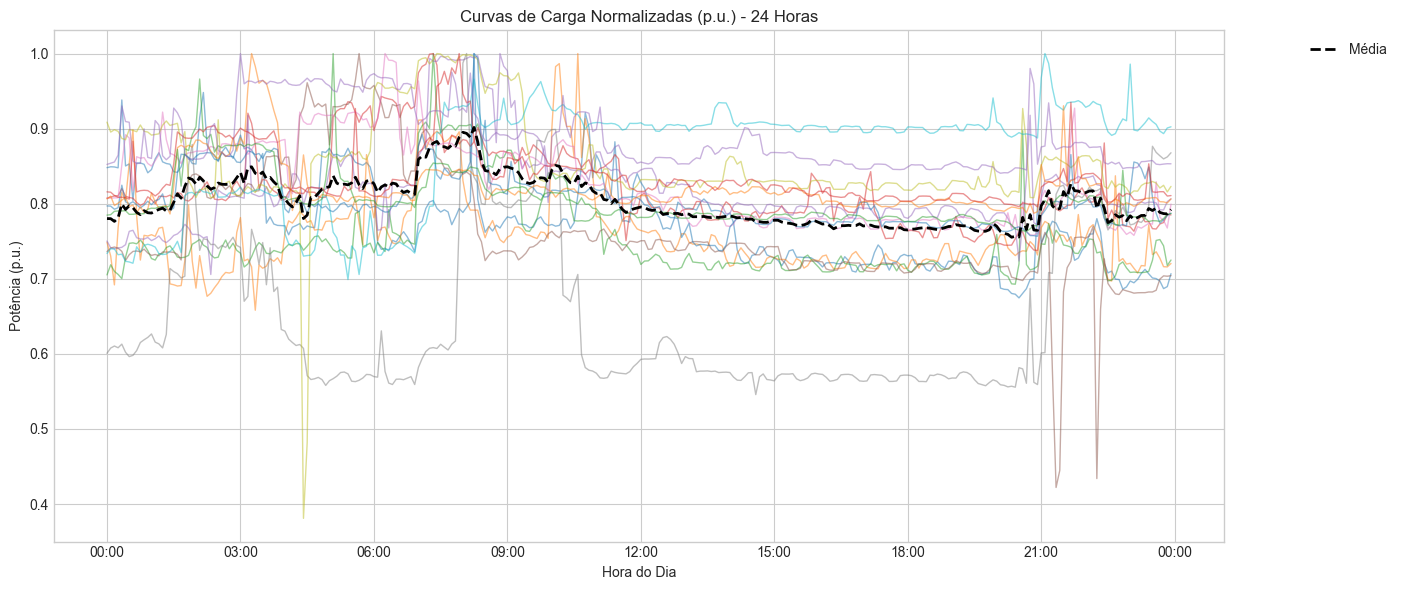

                     Load.671  Load.634a  Load.634b  Load.634c  Load.645  \
2000-01-01 00:00:00  0.848013   0.748686   0.705199   0.807253  0.750314   
2000-01-01 00:05:00  0.849223   0.730222   0.718679   0.808851  0.741444   
2000-01-01 00:10:00  0.848982   0.691923   0.709871   0.810404  0.739910   
2000-01-01 00:15:00  0.847831   0.767877   0.705819   0.810689  0.741126   
2000-01-01 00:20:00  0.938217   0.815136   0.700286   0.820009  0.741922   

                     Load.646  Load.692  Load.675a  Load.675b  Load.675c  \
2000-01-01 00:00:00  0.736149  0.807966   0.600800   0.908642   0.733714   
2000-01-01 00:05:00  0.740960  0.807459   0.607763   0.895434   0.739927   
2000-01-01 00:10:00  0.742337  0.807822   0.610465   0.898581   0.739817   
2000-01-01 00:15:00  0.740784  0.807895   0.608169   0.896355   0.732078   
2000-01-01 00:20:00  0.736520  0.851761   0.612961   0.887000   0.732817   

                     Load.611  Load.652  Load.670a  Load.670b  Load.670c  
2000-01-01 

In [22]:
if not df_curves.empty:
    plt.figure(figsize=(14, 6))
    
    # Plota todas as curvas
    plt.plot(df_curves.index, df_curves.values, alpha=0.5, linewidth=1)
    
    # Plota a média (curva em destaque)
    plt.plot(df_curves.index, df_curves.mean(axis=1), color='black', linewidth=2, linestyle='--', label='Média')
    
    plt.title('Curvas de Carga Normalizadas (p.u.) - 24 Horas')
    plt.xlabel('Hora do Dia')
    plt.ylabel('Potência (p.u.)')
    
    # Formata o eixo X para mostrar apenas horas e minutos
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()
    
    # Exibir primeiros registos
    print(df_curves.head())
else:
    print("Nenhum dado foi gerado para plotar.")

In [25]:
# 1. Constrói o caminho completo
# BASE_DIR já é ".../data", então adicionamos "curves" e o nome do arquivo
output_path = BASE_DIR / "curves" / "13BUS_curve.csv"

# 2. Garante que a pasta 'curves' exista
# parents=True cria pastas pai se necessário (ex: data/curves)
# exist_ok=True não dá erro se a pasta já existir
output_path.parent.mkdir(parents=True, exist_ok=True)

# 3. Salva o arquivo
df_curves.to_csv(output_path, index_label='timestamp')